In [309]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression    
from sklearn.preprocessing import MinMaxScaler,StandardScaler,RobustScaler
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score  

In [310]:
df=pd.read_csv("student_performance.csv")

In [311]:
df.head(10)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
5,3,78,No,9,6,61.0
6,7,73,Yes,5,6,63.0
7,8,45,Yes,4,6,42.0
8,5,77,No,8,2,61.0
9,4,89,No,4,0,69.0


In [312]:
df['Extracurricular Activities'].unique()

array(['Yes', 'No'], dtype=object)

In [313]:
# df['Extracurricular Activities']=df['Extracurricular Activities'].replace({'Yes':1, 'No':0})

In [314]:
x=df.drop(columns='Performance Index')
y=df['Performance Index']

In [315]:
x

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,Yes,9,1
1,4,82,No,4,2
2,8,51,Yes,7,2
3,5,52,Yes,5,2
4,7,75,No,8,5
...,...,...,...,...,...
9995,1,49,Yes,4,2
9996,7,64,Yes,8,5
9997,6,83,Yes,8,5
9998,9,97,Yes,7,0


In [316]:
y

0       91.0
1       65.0
2       45.0
3       36.0
4       66.0
        ... 
9995    23.0
9996    58.0
9997    74.0
9998    95.0
9999    64.0
Name: Performance Index, Length: 10000, dtype: float64

In [317]:
num_cols=x.select_dtypes(include='number').columns
num_cols
cat_col=x.select_dtypes(include='object').columns
cat_col

Index(['Extracurricular Activities'], dtype='object')

<Axes: >

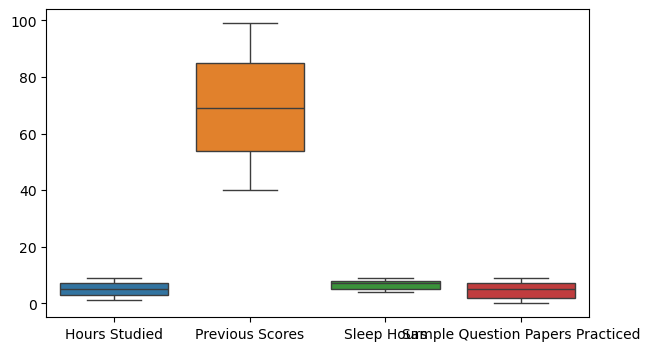

In [318]:
plt.figure(figsize=(7,4))
sns.boxplot(x[num_cols])

In [319]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42) 

In [320]:
xtrain,ytrain                  

(      Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
 9254              5               49                         No            7   
 1561              2               48                        Yes            7   
 1670              2               81                         No            7   
 6087              2               46                         No            6   
 6669              8               47                         No            9   
 ...             ...              ...                        ...          ...   
 5734              8               50                        Yes            6   
 5191              4               68                         No            9   
 5390              9               48                         No            7   
 860               1               47                         No            9   
 7270              2               46                         No            6   
 
       Sample Question Pap

In [321]:
scaling=MinMaxScaler()

In [322]:
xtrain[num_cols]=scaling.fit_transform(xtrain[num_cols])
xtrain

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
9254,0.500,0.152542,No,0.6,0.555556
1561,0.125,0.135593,Yes,0.6,0.666667
1670,0.125,0.694915,No,0.6,0.222222
6087,0.125,0.101695,No,0.4,0.111111
6669,0.875,0.118644,No,1.0,0.000000
...,...,...,...,...,...
5734,0.875,0.169492,Yes,0.4,0.666667
5191,0.375,0.474576,No,1.0,0.333333
5390,1.000,0.135593,No,0.6,0.666667
860,0.000,0.118644,No,1.0,0.000000


In [323]:
df.corr(numeric_only=True)

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000


## Label Encoder

In [324]:
# encoder=LabelEncoder()

In [325]:
# xtrain[cat_col]=encoder.fit_transform(xtrain[cat_col])  # error becoz it accepts only 1-D
# xtrain

In [326]:
# xtrain[cat_col]        # 2-D

In [327]:
# xtrain['Extracurricular Activities']=encoder.fit_transform(xtrain['Extracurricular Activities'])
# xtrain

## OneHot Encoder

In [328]:
encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore')

# xtrain[cat_col]=encoder.fit_transform(xtrain[cat_col])
'''
Error: ValueError: Columns must be same length as key
It means 
'''

values=encoder.fit_transform(xtrain[cat_col])
columns=encoder.get_feature_names_out()

In [329]:
xtrain[columns]=values
# xtrain
xtrain=xtrain.drop(columns=['Extracurricular Activities'])
xtrain 

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_No,Extracurricular Activities_Yes
9254,0.500,0.152542,0.6,0.555556,1.0,0.0
1561,0.125,0.135593,0.6,0.666667,0.0,1.0
1670,0.125,0.694915,0.6,0.222222,1.0,0.0
6087,0.125,0.101695,0.4,0.111111,1.0,0.0
6669,0.875,0.118644,1.0,0.000000,1.0,0.0
...,...,...,...,...,...,...
5734,0.875,0.169492,0.4,0.666667,0.0,1.0
5191,0.375,0.474576,1.0,0.333333,1.0,0.0
5390,1.000,0.135593,0.6,0.666667,1.0,0.0
860,0.000,0.118644,1.0,0.000000,1.0,0.0


In [330]:
xtest[num_cols]=scaling.transform(xtest[num_cols])

xtest_values=encoder.transform(xtest[cat_col])
xtest[columns]=xtest_values
xtest.drop(columns=['Extracurricular Activities'],inplace=True)
xtest

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_No,Extracurricular Activities_Yes
6252,0.500,0.491525,0.8,0.222222,1.0,0.0
4684,0.125,0.101695,0.0,0.888889,0.0,1.0
1731,0.750,0.271186,0.6,0.555556,0.0,1.0
4742,0.625,0.033898,0.8,0.555556,0.0,1.0
4521,0.750,0.220339,0.0,0.666667,1.0,0.0
...,...,...,...,...,...,...
6412,0.125,0.508475,0.6,0.333333,1.0,0.0
8285,0.375,0.661017,1.0,0.333333,1.0,0.0
7853,0.125,0.000000,0.6,0.222222,0.0,1.0
1095,0.250,0.728814,0.6,0.555556,1.0,0.0


In [331]:
model=LinearRegression()

In [336]:
model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [338]:
# Train_score
model.score(xtrain,ytrain)

0.9886898790682355

In [337]:
# Test_score
model.score(xtest,ytest)

0.9889832909573145

In [341]:
ytrain_pred=model.predict(xtrain)
train_score=r2_score(ytrain,ytrain_pred)
train_score

0.9886898790682355

In [342]:
ytest_pred=model.predict(xtest) 
test_score=r2_score(ytest,ytest_pred) 
test_score

0.9889832909573145

In [ ]:
input=[[12,35,1,10,5],[15,25,1,9,10]]
future_pred=model.predict(input) 
future_pred  


c:\Users\chand\anaconda3\Edunet\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([42.23963664, 41.10942216])

In [ ]:
model.predict(xtest)

array([54.71185392, 22.61551294, 47.90314471, ..., 16.79341955,
       63.34327368, 45.94262301])

In [ ]:
mean_squared_error(ytrain,ytrain_pred)

4.169735849525007

In [ ]:
mean_absolute_error(ytrain,ytrain_pred)

1.6193054830334268

In [ ]:
root_mean_squared_error(ytrain,ytrain_pred)

2.0419931071198567

<Axes: xlabel='Previous Scores', ylabel='Performance Index'>

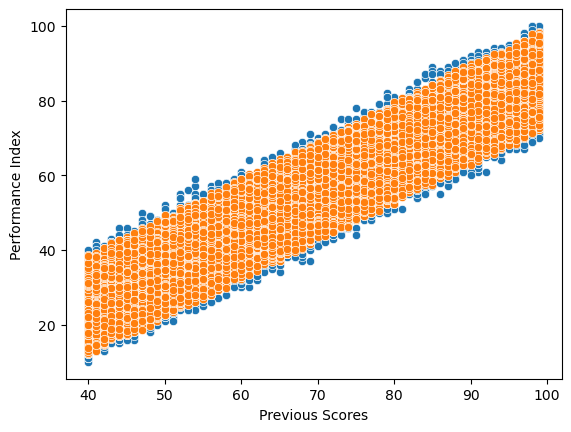

In [ ]:
# Train score prediction
sns.scatterplot(x=xtrain['Previous Scores'],y=ytrain)
sns.scatterplot(x=xtrain['Previous Scores'],y=ytrain_pred)

<Axes: xlabel='Previous Scores', ylabel='Performance Index'>

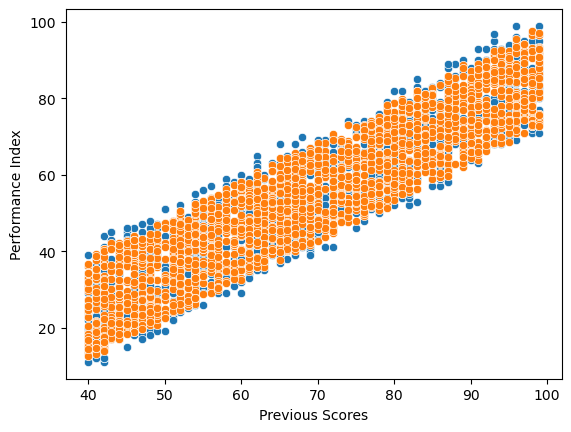

In [ ]:
# Test Data 
sns.scatterplot(x=xtest['Previous Scores'],y=ytest)
sns.scatterplot(x=xtest['Previous Scores'],y=ytest_pred)